In [2]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "etna_data"

sys.path.append(str(SRC_DIR))

from cause_trigger import (
    CauseTriggerConfig,
    run_cause_trigger,
    find_increase_split,
)

In [3]:
def check_import(package_name):
    try:
        __import__(package_name)
        print(f"OK: {package_name}")
    except ImportError as e:
        print(f"MISSING: {package_name} -> {e}")

check_import("numpy")
check_import("pandas")
check_import("sklearn")
check_import("scipy")
check_import("tigramite")
check_import("hmml")

OK: numpy
OK: pandas
OK: sklearn
OK: scipy
OK: tigramite
OK: hmml


In [4]:
etna_path = DATA_DIR / "FINAL_ME01_scaled.csv"

etna = pd.read_csv(etna_path, parse_dates=["time"])

print(etna.shape)
display(etna.head())
display(etna.isna().mean().sort_values())

(4608, 11)


,time,station,S_log_scaled,T_log_scaled,Y_log_scaled,CO2_3_scaled,AirTemp_3_scaled,Patm_3_scaled,WindSpeed_scaled,Rain_scaled,CO2_SO2_scaled
0,2008-04-12 00:00:00+00:00,ME01,-1.144708,0.376528,-1.386552,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113
1,2008-04-12 00:10:00+00:00,ME01,-0.890891,-0.813940,-1.349344,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113
2,2008-04-12 00:20:00+00:00,ME01,-0.937013,1.466606,-1.317024,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113
3,2008-04-12 00:30:00+00:00,ME01,-1.007280,-0.556681,-1.315232,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113
4,2008-04-12 00:40:00+00:00,ME01,-0.836284,7.841066,-1.310560,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113


time                0.0
station             0.0
S_log_scaled        0.0
T_log_scaled        0.0
Y_log_scaled        0.0
CO2_3_scaled        0.0
AirTemp_3_scaled    0.0
Patm_3_scaled       0.0
WindSpeed_scaled    0.0
Rain_scaled         0.0
CO2_SO2_scaled      0.0
dtype: float64

In [7]:
X_all = (
    etna
    .drop(columns=["station"], errors="ignore")
    .set_index("time")
    .sort_index()
)

X_all = X_all.select_dtypes(include=[np.number])

print(X_all.shape)
display(X_all.head())
display(X_all.isna().sum())

(4608, 9)


,S_log_scaled,T_log_scaled,Y_log_scaled,CO2_3_scaled,AirTemp_3_scaled,Patm_3_scaled,WindSpeed_scaled,Rain_scaled,CO2_SO2_scaled
time,,,,,,,,,
2008-04-12 00:00:00+00:00,-1.144708,0.376528,-1.386552,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113
2008-04-12 00:10:00+00:00,-0.890891,-0.813940,-1.349344,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113
2008-04-12 00:20:00+00:00,-0.937013,1.466606,-1.317024,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113
2008-04-12 00:30:00+00:00,-1.007280,-0.556681,-1.315232,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113
2008-04-12 00:40:00+00:00,-0.836284,7.841066,-1.310560,-1.455485,0.360327,-1.961611,-0.674491,-0.123581,1.215113


S_log_scaled        0
T_log_scaled        0
Y_log_scaled        0
CO2_3_scaled        0
AirTemp_3_scaled    0
Patm_3_scaled       0
WindSpeed_scaled    0
Rain_scaled         0
CO2_SO2_scaled      0
dtype: int64

In [6]:
etna_event_time = pd.Timestamp("2008-05-12 06:28:00", tz="UTC")

start = pd.Timestamp("2008-05-12 00:00:00", tz="UTC")
end = pd.Timestamp("2008-05-13 12:00:00", tz="UTC")

X_event = X_all.loc[start:end].copy()

print(X_event.shape)
print(X_event.index.min(), "to", X_event.index.max())
display(X_event.head())

(217, 9)
2008-05-12 00:00:00+00:00 to 2008-05-13 12:00:00+00:00


,S_log_scaled,T_log_scaled,Y_log_scaled,CO2_3_scaled,AirTemp_3_scaled,Patm_3_scaled,WindSpeed_scaled,Rain_scaled,CO2_SO2_scaled
time,,,,,,,,,
2008-05-12 00:00:00+00:00,-0.296839,0.895830,-1.436675,1.36082,-0.753994,-0.209531,-0.674491,-0.123581,-2.800939
2008-05-12 00:10:00+00:00,-0.187116,0.640646,-1.439982,1.36082,-0.753994,-0.209531,-0.674491,-0.123581,-2.800939
2008-05-12 00:20:00+00:00,-0.225635,0.467435,-1.434308,1.36082,-0.753994,-0.209531,-0.674491,-0.123581,-2.800939
2008-05-12 00:30:00+00:00,-0.233534,0.762335,-0.981876,1.36082,-0.753994,-0.209531,-0.674491,-0.123581,-2.800939
2008-05-12 00:40:00+00:00,-0.446608,0.215325,-1.465246,1.36082,-0.753994,-0.209531,-0.674491,-0.123581,-2.800939


In [8]:
def split_diagnostics(X, target, event_time=None, min_interval_length=30):
    split_idx = find_increase_split(
        X[target],
        min_interval_length=min_interval_length,
    )

    if split_idx is None:
        return {
            "target": target,
            "split_index": None,
            "split_time": None,
            "I1_length": None,
            "I2_length": None,
            "abs_mean_I1": None,
            "abs_mean_I2": None,
            "abs_mean_difference": None,
            "distance_to_event": None,
        }

    I1 = X.iloc[:split_idx]
    I2 = X.iloc[split_idx:]

    split_time = X.index[split_idx]

    out = {
        "target": target,
        "split_index": split_idx,
        "split_time": split_time,
        "I1_length": len(I1),
        "I2_length": len(I2),
        "abs_mean_I1": abs(I1[target].mean()),
        "abs_mean_I2": abs(I2[target].mean()),
        "abs_mean_difference": abs(I2[target].mean()) - abs(I1[target].mean()),
        "distance_to_event": None,
    }

    if event_time is not None:
        out["distance_to_event"] = split_time - event_time

    return out


candidate_targets = [
    "T_log_scaled",   # known teleseismic trigger band; good sanity check
    "Y_log_scaled",   # high-frequency response/effect band
    "S_log_scaled",   # background/state band
]

split_table = pd.DataFrame([
    split_diagnostics(
        X_event,
        target=t,
        event_time=etna_event_time,
        min_interval_length=30,
    )
    for t in candidate_targets
])

display(split_table)

,target,split_index,split_time,I1_length,I2_length,abs_mean_I1,abs_mean_I2,abs_mean_difference,distance_to_event
0,T_log_scaled,39,2008-05-12 06:30:00+00:00,39,178,0.878861,11.078371,10.199510,0 days 00:02:00
1,Y_log_scaled,181,2008-05-13 06:10:00+00:00,181,36,1.026022,10.850127,9.824105,0 days 23:42:00
2,S_log_scaled,186,2008-05-13 07:00:00+00:00,186,31,0.782587,24.215908,23.433321,1 days 00:32:00


In [9]:
def summarize_result(result):
    print("Backend:", result.get("backend"))
    print("Split index:", result.get("split_index"))
    print("B2:", result.get("B_2"))
    print("Trigger candidates:", result.get("T_candidates"))
    print("Accepted triggers:", result.get("T"))
    print("Causes:", result.get("C"))
    print("Pairs:", result.get("pairs"))

    diag = pd.DataFrame(result.get("diagnostics", []))

    if len(diag) > 0:
        sort_cols = [c for c in ["accepted", "rss_reduction_ratio", "f_stat"] if c in diag.columns]

        if "rss_reduction_ratio" in diag.columns:
            diag = diag.sort_values("rss_reduction_ratio", ascending=False)

        display(diag)

    return diag

In [10]:
config_pcmci_T = CauseTriggerConfig(
    y_t="T_log_scaled",
    lags=3,
    causal_backend="pcmci",
    alpha=0.05,
    min_interval_length=30,
    beta_is_ones=True,
    exclude_target_from_triggers=False,

    # PCMCI settings
    pcmci_pc_alpha=0.05,
    pcmci_alpha_level=0.05,
    pcmci_fdr_method="fdr_bh",
    pcmci_cond_ind_test="parcorr",
    pcmci_verbosity=0,
)

result_pcmci_T = run_cause_trigger(X_event, config_pcmci_T)
diag_pcmci_T = summarize_result(result_pcmci_T)

Backend: pcmci
Split index: 39
B2: ['S_log_scaled', 'T_log_scaled']
Trigger candidates: ['S_log_scaled', 'T_log_scaled']
Accepted triggers: ['T_log_scaled']
Causes: ['T_log_scaled']
Pairs: [('T_log_scaled', 'T_log_scaled')]


,accepted,f_stat,critical_f,rss_reduced,rss_full,rss_reduction,rss_reduction_ratio,gamma_1,gamma_2,r,trigger,cause
1,True,132.972304,3.895773,188999.238750,106862.182826,82137.055924,0.434589,-0.155562,0.018720,175,T_log_scaled,T_log_scaled
0,False,0.577546,3.895773,69306.445946,69075.842145,230.603801,0.003327,0.266531,0.001913,175,S_log_scaled,T_log_scaled


In [11]:
result_pcmci_T.get("causal_lags")

{'S_log_scaled': [2], 'T_log_scaled': [1, 2, 3]}

In [12]:
result_pcmci_T.get("causal_scores")

{'S_log_scaled': {'min_q': 0.001044932628394622,
  'max_abs_val': 0.3119020143623759,
  'best_lag': 2},
 'T_log_scaled': {'min_q': 1.6694086828386316e-08,
  'max_abs_val': 0.45812378481662897,
  'best_lag': 3}}

In [13]:
config_pcmci_Y = CauseTriggerConfig(
    y_t="Y_log_scaled",
    lags=3,
    causal_backend="pcmci",
    alpha=0.05,
    min_interval_length=30,
    beta_is_ones=True,
    exclude_target_from_triggers=False,

    pcmci_pc_alpha=0.05,
    pcmci_alpha_level=0.05,
    pcmci_fdr_method="fdr_bh",
    pcmci_cond_ind_test="parcorr",
    pcmci_verbosity=0,
)

result_pcmci_Y = run_cause_trigger(X_event, config_pcmci_Y)
diag_pcmci_Y = summarize_result(result_pcmci_Y)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  val, _ = stats.pearsonr(x_vals, y_vals)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\tigramite\independence_tests\parcorr.py:146: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  val, _ = stats.pearsonr(x_vals, y_vals)


Backend: pcmci
Split index: 181
B2: []
Trigger candidates: []
Accepted triggers: []
Causes: []
Pairs: []


In [14]:
config_hmml_T = CauseTriggerConfig(
    y_t="T_log_scaled",
    lags=3,
    distribution="gaussian",
    causal_backend="hmml",
    alpha=0.05,
    min_interval_length=30,
    beta_is_ones=True,
    exclude_target_from_triggers=False,
)

result_hmml_T = run_cause_trigger(X_event, config_hmml_T)
diag_hmml_T = summarize_result(result_hmml_T)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


Backend: hmml
Split index: 39
B2: ['T_log_scaled']
Trigger candidates: ['T_log_scaled']
Accepted triggers: []
Causes: []
Pairs: []


In [15]:
config_hmml_Y = CauseTriggerConfig(
    y_t="Y_log_scaled",
    lags=3,
    distribution="gaussian",
    causal_backend="hmml",
    alpha=0.05,
    min_interval_length=30,
    beta_is_ones=True,
    exclude_target_from_triggers=False,
)

result_hmml_Y = run_cause_trigger(X_event, config_hmml_Y)
diag_hmml_Y = summarize_result(result_hmml_Y)

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\scipy\optimize\_optimize.py:3049: RuntimeWarning: invalid value encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


Backend: hmml
Split index: 181
B2: ['AirTemp_3_scaled', 'Patm_3_scaled', 'Rain_scaled', 'CO2_SO2_scaled']
Trigger candidates: ['Patm_3_scaled']
Accepted triggers: ['Patm_3_scaled']
Causes: ['S_log_scaled']
Pairs: [('S_log_scaled', 'Patm_3_scaled')]


,accepted,f_stat,critical_f,rss_reduced,rss_full,rss_reduction,rss_reduction_ratio,gamma_1,gamma_2,r,trigger,cause
0,True,166.72442,4.159615,2062.66973,323.393346,1739.276384,0.843216,-44.141044,-36.054691,33,Patm_3_scaled,S_log_scaled


In [16]:
def compact_result_row(name, target, result):
    return {
        "run": name,
        "target": target,
        "backend": result.get("backend"),
        "split_index": result.get("split_index"),
        "B2": result.get("B_2"),
        "T_candidates": result.get("T_candidates"),
        "accepted_triggers": result.get("T"),
        "causes": result.get("C"),
        "pairs": result.get("pairs"),
    }


comparison = pd.DataFrame([
    compact_result_row("pcmci_T", "T_log_scaled", result_pcmci_T),
    compact_result_row("pcmci_Y", "Y_log_scaled", result_pcmci_Y),
    compact_result_row("hmml_T", "T_log_scaled", result_hmml_T),
    compact_result_row("hmml_Y", "Y_log_scaled", result_hmml_Y),
])

display(comparison)

,run,target,backend,split_index,B2,T_candidates,accepted_triggers,causes,pairs
0,pcmci_T,T_log_scaled,pcmci,39,"[S_log_scaled, T_log_scaled]","[S_log_scaled, T_log_scaled]",[T_log_scaled],[T_log_scaled],"[(T_log_scaled, T_log_scaled)]"
1,pcmci_Y,Y_log_scaled,pcmci,181,[],[],[],[],[]
2,hmml_T,T_log_scaled,hmml,39,[T_log_scaled],[T_log_scaled],[],[],[]
3,hmml_Y,Y_log_scaled,hmml,181,"[AirTemp_3_scaled, Patm_3_scaled, Rain_scaled,...",[Patm_3_scaled],[Patm_3_scaled],[S_log_scaled],"[(S_log_scaled, Patm_3_scaled)]"


In [17]:
def add_run_label(diag, run_name, target, backend):
    if diag is None or len(diag) == 0:
        return pd.DataFrame()

    out = diag.copy()
    out["run"] = run_name
    out["target"] = target
    out["backend"] = backend
    return out


all_diag = pd.concat(
    [
        add_run_label(diag_pcmci_T, "pcmci_T", "T_log_scaled", "pcmci"),
        add_run_label(diag_pcmci_Y, "pcmci_Y", "Y_log_scaled", "pcmci"),
        add_run_label(diag_hmml_T, "hmml_T", "T_log_scaled", "hmml"),
        add_run_label(diag_hmml_Y, "hmml_Y", "Y_log_scaled", "hmml"),
    ],
    ignore_index=True,
)

display(
    all_diag.sort_values(
        ["accepted", "rss_reduction_ratio"],
        ascending=[False, False],
    )
)

,accepted,f_stat,critical_f,rss_reduced,rss_full,rss_reduction,rss_reduction_ratio,gamma_1,gamma_2,r,trigger,cause,run,target,backend
2,True,166.724420,4.159615,2062.669730,323.393346,1739.276384,0.843216,-44.141044,-36.054691,33,Patm_3_scaled,S_log_scaled,hmml_Y,Y_log_scaled,hmml
0,True,132.972304,3.895773,188999.238750,106862.182826,82137.055924,0.434589,-0.155562,0.018720,175,T_log_scaled,T_log_scaled,pcmci_T,T_log_scaled,pcmci
1,False,0.577546,3.895773,69306.445946,69075.842145,230.603801,0.003327,0.266531,0.001913,175,S_log_scaled,T_log_scaled,pcmci_T,T_log_scaled,pcmci


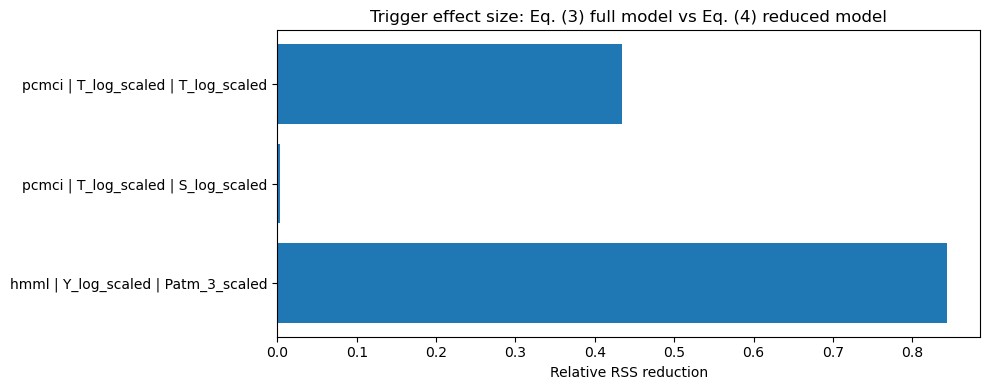

In [18]:
import matplotlib.pyplot as plt

plot_df = all_diag.dropna(subset=["rss_reduction_ratio"]).copy()

if len(plot_df) > 0:
    plot_df["label"] = (
        plot_df["backend"].astype(str)
        + " | "
        + plot_df["target"].astype(str)
        + " | "
        + plot_df["trigger"].astype(str)
    )

    plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
    plt.barh(plot_df["label"], plot_df["rss_reduction_ratio"])
    plt.xlabel("Relative RSS reduction")
    plt.title("Trigger effect size: Eq. (3) full model vs Eq. (4) reduced model")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()